|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>Autoencoders<h1>|
|<h2>Lecture:</h2>|<h1><b>Denoising MNIST<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Import and process the data

In [2]:
# download MNIST dataset
output_dir = 'sample_data'
mnist = datasets.MNIST(root='sample_data', download=True)

# extract labels (number IDs) and data
labels = mnist.targets.numpy()
data = mnist.data.numpy().reshape(mnist.data.shape[0], -1)  # flatten to 2D

# normalize the data to a range of [0 1]
dataNorm = data / np.max(data)

# convert to tensor
dataT = torch.tensor( dataNorm ).float()

print(labels.shape)
print(data.shape)

(60000,)
(60000, 784)


# Create the DL model

In [3]:
# create a class for the model
def createTheMNISTAE(nInput:int=784, nEncDec:int=250, nLat:int=50, lr:float=.001, seed=None):

  class aenet(nn.Module):
    def __init__(self, nInput:int=784, nEncDec:int=250, nLat:int=50, seed=None):
      super().__init__()
      
      if isinstance(seed, (int, float)):
        torch.manual_seed(int(seed))

      ### input layer
      self.input = nn.Linear(nInput,nEncDec)

      ### encoder layer
      self.enc = nn.Linear(self.input.out_features,nLat)

      ### latent layer
      self.lat = nn.Linear(self.enc.out_features,nEncDec)

      ### decoder layer
      self.dec = nn.Linear(self.lat.out_features,nInput)

    # forward pass
    def forward(self,x):
      x = F.relu( self.input(x) )
      x = F.relu( self.enc(x) )
      x = F.relu( self.lat(x) )
      return torch.sigmoid( self.dec(x) )

  # create the model instance
  net = aenet(nInput=nInput, nEncDec=nEncDec, nLat=nLat, seed=seed)

  # loss function
  lossfun = nn.MSELoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=lr)

  return net,lossfun,optimizer

In [4]:
# test the model with a bit of data
net,lossfun,optimizer = createTheMNISTAE()

X = dataT[:5,:]
yHat = net(X)

print(X.shape)
print(yHat.shape)

torch.Size([5, 784])
torch.Size([5, 784])


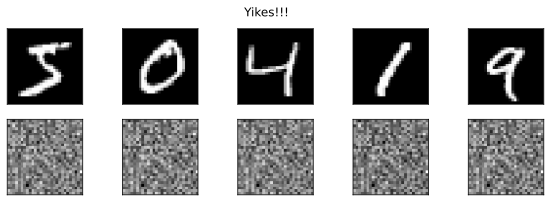

In [5]:
# let's see what the model did!
fig,axs = plt.subplots(2,5,figsize=(10,3))

for i in range(5):
  axs[0,i].imshow(X[i,:].view(28,28).detach() ,cmap='gray')
  axs[1,i].imshow(yHat[i,:].view(28,28).detach() ,cmap='gray')
  axs[0,i].set_xticks([]), axs[0,i].set_yticks([])
  axs[1,i].set_xticks([]), axs[1,i].set_yticks([])

plt.suptitle('Yikes!!!')
plt.show()

# Create a function that trains the model

In [6]:
def function2trainTheModel(numepochs:int, batchsize:int,
                           nInput:int=784, nEncDec:int=250, nLat:int=50, lr:float=0.001, seed=None):

  # create a new model
  net,lossfun,optimizer = createTheMNISTAE(nInput=nInput, nEncDec=nEncDec, nLat=nLat, lr=lr, seed=seed)
  
  # initialize losses
  losses = torch.zeros(numepochs)

  # loop over epochs
  for epochi in range(numepochs):
    
    # Generate random inedexes list over the dataset
    randomidx_list = np.random.choice(dataT.shape[0],size=dataT.shape[0])
    num_batches = int(randomidx_list.shape[0] // batchsize)
    
    batchLoss = []
    
    for batchi in range(num_batches):
      # Select random batch
      randomidxs = randomidx_list[batchi*batchsize:(batchi+1)*batchsize]
      X = dataT[randomidxs,:]

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,X)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batchLoss.append( loss.item() )
    # losses in this epoch
    losses[epochi] = np.mean(batchLoss)
  # end epochs

  # function output
  return losses, net

# Run the model and show the results!

In [7]:
# train the model (90s)
fn_msg = lambda cnt, total, loss, nEncDec, nLat: \
    f'Finished experiment {cnt:03}/{total:03}, nEncDec: {nEncDec}, nLat: {nLat}, final loss {loss:.4f}'

lr=.001
seed = 41
batchsize = 32
numepochs = 3
nEncDec_list = np.linspace(10,500,12).astype(int)  # 12
nLat_list = np.linspace(5,100,8).astype(int) # 8
num_experiments = nEncDec_list.shape[0] * nLat_list.shape[0]

avg_losses = np.zeros( (nEncDec_list.shape[0], nLat_list.shape[0]) )
losses_result = []

cnt = 1
num_losses2average = 3
for i, nEncDec in enumerate(nEncDec_list):
  for j, nLat in enumerate(nLat_list):
    losses, net = function2trainTheModel(numepochs, batchsize, nEncDec=nEncDec, nLat=nLat, lr=lr, seed=seed)
    losses_result.append( (nEncDec, nLat, losses) )
    avg_losses[i,j] = torch.mean( losses[-num_losses2average:] ).detach().item()
    print(fn_msg(cnt, num_experiments, losses[-1], nEncDec, nLat), end='\r')
    cnt += 1
print()

Finished experiment 096/096, nEncDec: 500, nLat: 100, final loss 0.0054


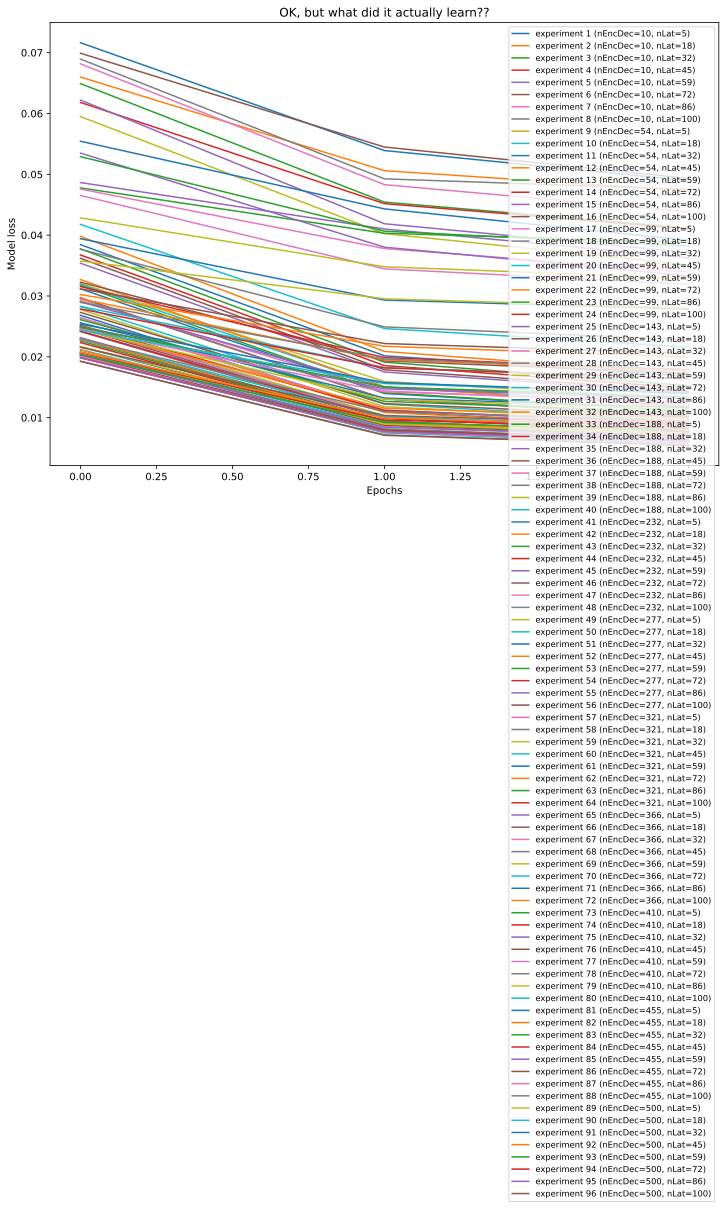

In [8]:
# visualize the losses
fig = plt.figure(figsize=(12,8))
for i, (nEncDec, nLat, losses) in enumerate(losses_result):
    plt.plot(losses, label=f'experiment {i+1} (nEncDec={nEncDec}, nLat={nLat})')
plt.xlabel('Epochs')
plt.ylabel('Model loss')
plt.title('OK, but what did it actually learn??')
plt.legend(loc='best', fontsize='small')
plt.show()

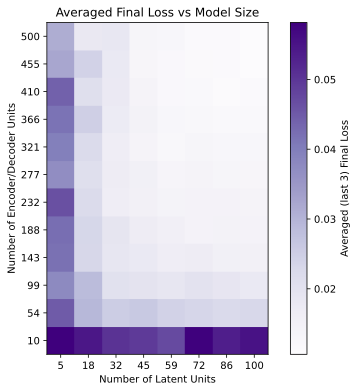

In [18]:
# Visualize averaged losses matrix
fig = plt.figure(figsize=(8,6))
plt.imshow(avg_losses,cmap='Purples',origin='lower')
plt.colorbar(label=f'Averaged (last {num_losses2average}) Final Loss')
plt.xticks(ticks=np.arange(len(nLat_list)), labels=nLat_list)
plt.yticks(ticks=np.arange(len(nEncDec_list)), labels=nEncDec_list)
plt.xlabel('Number of Latent Units')
plt.ylabel('Number of Encoder/Decoder Units')
plt.title('Averaged Final Loss vs Model Size')
plt.show()

# Additional explorations

In [10]:
# 1) Because the full experiment takes a long time, it's not pratical to add another factor. Fix the number of encoder
#    units to 100 and instead parametrically explore the learning rate. You don't need so many learning rates, just use
#    [.0001, .001, .01]. The results can be shown in a line plot, with one line per lr and bottleneck units on the x-axis.
#
# 2) Smooth transitions across parameters are easy to interpret. But the image plot shows a sharp transition for small
#    numbers of bottleneck units. This rings alarm bells for any experimental scientist! It means that something is
#    happening at that region of parameter space and you should investigate. Thus, re-run the experiment but change the
#    parameters to focus specifically on the region of the parameter space where there are large changes in the results.
#